In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


=== Missing Values Summary ===
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


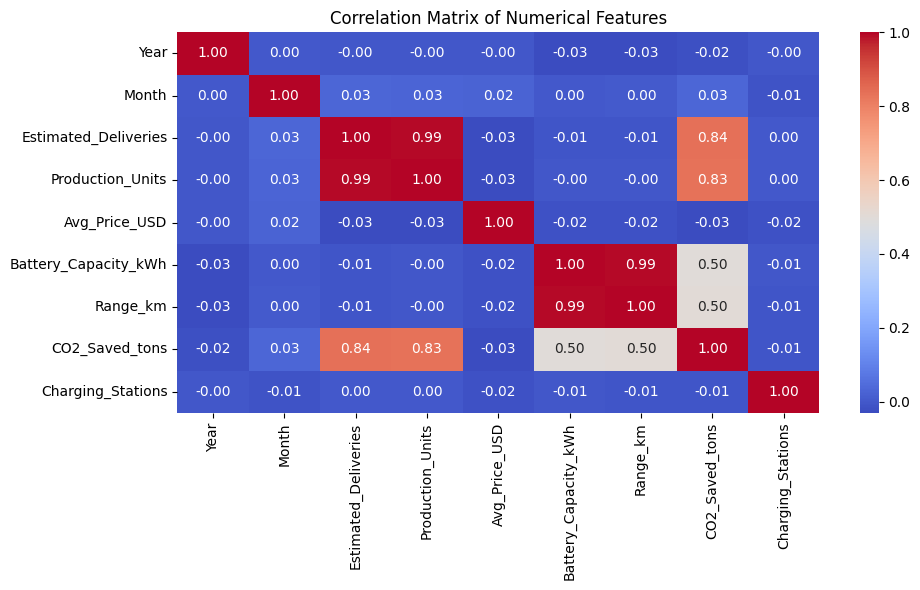

In [3]:
print("=== Missing Values Summary ===")
print(df.isna().sum())

# Correlation Heatmap for Numerical Features
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10, 6))
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [4]:
# Create a continuous time-based feature
df['Time_Index'] = df['Year'] + (df['Month'] / 12)

# Arrange records in chronological order
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

# Define features and target variable
feature_set = df.drop('Estimated_Deliveries', axis=1)
target_values = df['Estimated_Deliveries']

# Identify column types automatically
categorical_features = feature_set.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_features = feature_set.select_dtypes(include=['number']).columns.tolist()

print("Numeric Columns:")
print(numeric_features)

print("\nCategorical Columns:")
print(categorical_features)

Numeric Columns:
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Time_Index']

Categorical Columns:
['Region', 'Model', 'Source_Type']


In [5]:
# Preprocessing pipeline for numerical attributes
num_pipeline = Pipeline([
    ('fill_missing', SimpleImputer(strategy='median')),
    ('standardize', StandardScaler())
])

# Preprocessing pipeline for categorical attributes
cat_pipeline = Pipeline([
    ('fill_missing', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both pipelines into a single transformer
data_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', num_pipeline, numeric_features),
        ('categorical', cat_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline configured successfully.")

Preprocessing pipeline configured successfully.


In [6]:

# Preserve chronological order while creating train and test sets
train_size = int(len(df) * 0.80)

X_train = feature_set.iloc[:train_size]
X_test = feature_set.iloc[train_size:]

y_train = target_values.iloc[:train_size]
y_test = target_values.iloc[train_size:]

print(f"Number of training records: {len(X_train)}")
print(f"Number of testing records: {len(X_test)}")

Number of training records: 2112
Number of testing records: 528


In [7]:
# Random Forest workflow
rf_model = Pipeline([
    ('preprocessing', data_preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# XGBoost workflow
xgb_model = Pipeline([
    ('preprocessing', data_preprocessor),
    ('model', XGBRegressor(
        random_state=42,
        enable_categorical=True
    ))
])

# Train both models
print("Fitting Random Forest model...")
rf_model.fit(X_train, y_train)

print("Fitting XGBoost model...")
xgb_model.fit(X_train, y_train)

print("Model training completed successfully.")

Fitting Random Forest model...
Fitting XGBoost model...
Model training completed successfully.


In [8]:
# Time-aware cross validation
time_cv = TimeSeriesSplit(n_splits=3)

# Hyperparameter search space
search_space = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2]
}

# Randomized search for XGBoost tuning
xgb_tuner = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=search_space,
    n_iter=5,
    cv=time_cv,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

print("Running hyperparameter optimization...")
xgb_tuner.fit(X_train, y_train)

best_xgb_model = xgb_tuner.best_estimator_

print("Best Parameters:")
print(xgb_tuner.best_params_)

Running hyperparameter optimization...
Best Parameters:
{'model__n_estimators': 50, 'model__max_depth': 5, 'model__learning_rate': 0.2}


Random Forest -> MAE: 329.60 | R²: 0.9876
Tuned XGBoost -> MAE: 289.45 | R²: 0.9905


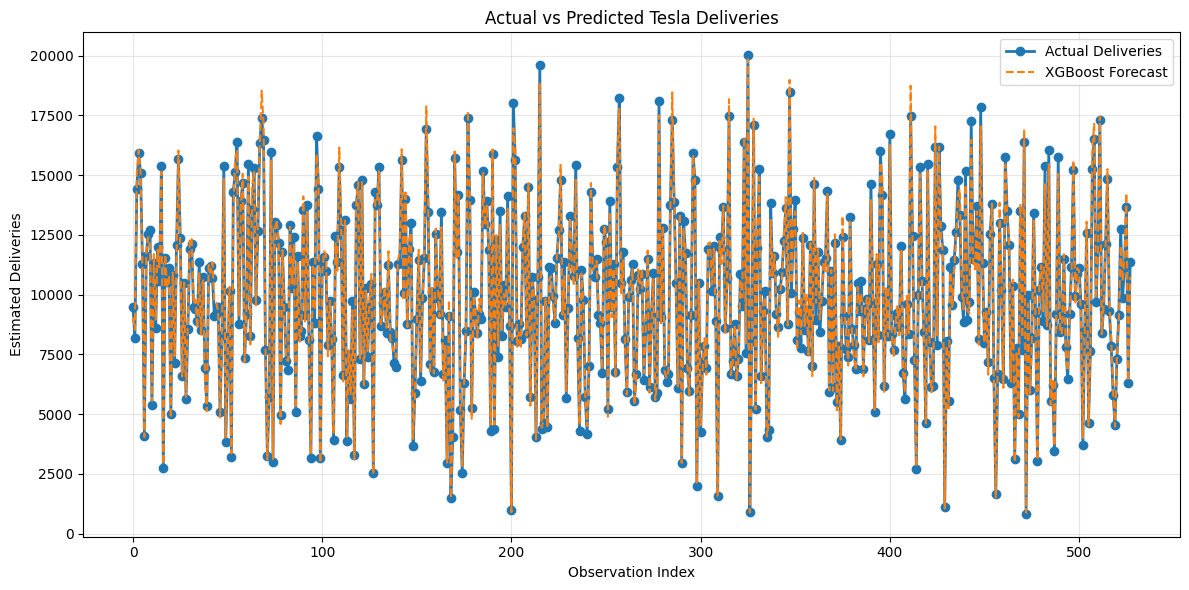

In [9]:
# Generate predictions on the test dataset
rf_predictions = rf_model.predict(X_test)
xgb_predictions = best_xgb_model.predict(X_test)

# Evaluate model performance
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"Random Forest -> MAE: {rf_mae:.2f} | R²: {rf_r2:.4f}")
print(f"Tuned XGBoost -> MAE: {xgb_mae:.2f} | R²: {xgb_r2:.4f}")

# Compare actual and predicted delivery values
plt.figure(figsize=(12, 6))

plt.plot(
    y_test.values,
    label="Actual Deliveries",
    marker='o',
    linewidth=2
)

plt.plot(
    xgb_predictions,
    label="XGBoost Forecast",
    linestyle='--'
)

plt.title("Actual vs Predicted Tesla Deliveries")
plt.xlabel("Observation Index")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import mean_squared_error
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Tuned XGBoost RMSE: {xgb_rmse:.2f}")

Random Forest RMSE: 409.02
Tuned XGBoost RMSE: 357.64


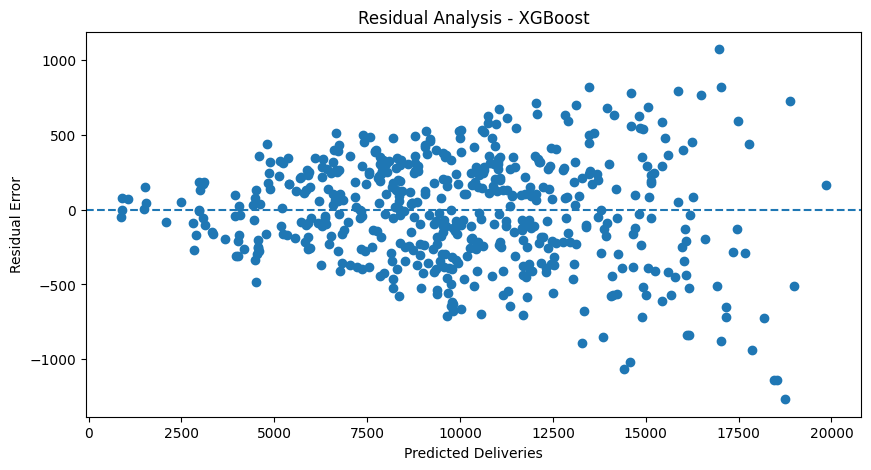

In [11]:
residuals = y_test - xgb_predictions

plt.figure(figsize=(10,5))
plt.scatter(xgb_predictions, residuals)
plt.axhline(y=0, linestyle='--')
plt.title("Residual Analysis - XGBoost")
plt.xlabel("Predicted Deliveries")
plt.ylabel("Residual Error")
plt.show()

### Key Findings

- Tesla deliveries show a strong temporal trend over the years.
- XGBoost achieved lower prediction error compared to Random Forest.
- Time-based features contributed significantly to forecasting performance.
- The model can be used to estimate future delivery demand and production planning.